# OVRO-LWA HEALPix nested-tile detect (Option 2)

Experiment: coadd hourly FITS onto a **HEALPix** map (`nside_map=2048`), write MAP+WEIGHT FITS,
export a **HiPS** directory (same stem, `.hips` suffix), project **nested** tiles
(`nside_tile=4`, TAN, `align="diamond"`, `margin=0.05`) via `reproject_from_healpix`, then
`run_pybdsf_on_hdu` on each tile — once per band in `COLOR_BANDS`.

Tile catalogs are collapsed with `merge_tile_metacatalog` into **LST-merged-shaped**
Parquets (`metacatalog_lst_{band}.parquet`), then fused with the same
**band merge** path as `ovro_lwa_metacatalog.ipynb` (`build_global_metacatalog`).

This is a sibling to `ovro_lwa_mosaic_detect.ipynb` (planar SIN coadd). It does **not** replace
the per-hour → LST-merge catalog pipeline.

**Notes**
- Do **not** call `blank_below_elevation` on tile HDUs (CRVAL is tile center, not zenith).
- Elevation blanking uses an **elliptical** horizon cut (`min_elevation_ns` / `min_elevation_ew`) on native hourly WCS.
- Overlap duplicates are merged (brightest flux); `n_lst_contributions=1` (single coadd).
- Requires `lwa-catalog[analyze,detect]` and a current editable `lwa-healpix`.


In [1]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.io import fits

from lwa_catalog.constants import ASSOC_BANDS, BAND_FIELDS, BAND_FLUX_FIELDS
from lwa_catalog.create.discover import discover_fits_files, discovered_slots
from lwa_catalog.create.healpix_detect import (
    detect_sources_on_healpix_tiles,
    median_beam_from_paths,
    restfreq_hz_from_header,
)
from lwa_catalog.create.merge import build_global_metacatalog, merge_tile_metacatalog
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    write_lst_merged,
    write_metacatalog,
    write_table,
)
from lwa_catalog.paths import CatalogLayout
from lwa_healpix import (
    coadd_fits,
    healpix_to_hips,
    parallactic_delta_q_edge_summary,
    read_healpix_fits,
    write_healpix_fits,
)

# --- paths (edit for your machine) ---
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/Coadd/Run_20260909_000000/")
# Glob(s) relative to FITS_ROOT (rglob). Band comes from the path/filename
# (see Filename parsing / COLOR_BANDS below).
FITS_GLOB = "??h/[RGBF]*/*_I_deep_Taper_Robust-0.75_shflux_pbcorr*fits"
OUTPUT_DIR = Path("/fast/claw/healpix_tile_detect2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

REUSE_HEALPIX_FITS = True
REUSE_HIPS = True
# Skip tile detect + tile→LST merge when metacatalog_lst_*.parquet exist for COLOR_BANDS
REUSE_CACHED_CATALOGS = True

NSIDE_MAP = 2048
NSIDE_TILE = 4
TILE_ALIGN = "diamond"  # "celestial" + OVERLAP for legacy north-aligned squares
TILE_MARGIN = 0.05      # pad beyond HEALPix diamond vertices (diamond align)
OVERLAP = 0.2          # only used when TILE_ALIGN == "celestial"
MIN_ELEVATION_NS_DEG = 15.0  # N/S horizon cut (looser)
MIN_ELEVATION_EW_DEG = 40.0  # E/W horizon cut (stricter)
COORD_FRAME = "icrs"  # reproject: icrs/c or galactic/g
NESTED = True

BDSF_KW = dict(
    thresh="hard",
    thresh_isl=2.0,
    thresh_pix=3.0,
    rms_map=True,
    savefits_rmsim=False,
    outdir=str(OUTPUT_DIR),
    kappa_clip=3.0,
    rms_box=(256, 64),
    adaptive_rms_box=True,
    rms_box_bright=(32, 8),
    adaptive_thresh=50.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=1,
)


def healpix_fits_path(band: str) -> Path:
    return OUTPUT_DIR / f"healpix_{band}_nside{NSIDE_MAP}.fits"


def healpix_hips_path(band: str) -> Path:
    return healpix_fits_path(band).with_suffix(".hips")


def tile_catalog_path(band: str) -> Path:
    return OUTPUT_DIR / f"sources_healpix_tiles_{band}.parquet"


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
slots = discovered_slots(fits_files)

paths_by_band: dict[str, list[Path]] = {}
for band in COLOR_BANDS:
    by_lst: dict[str, object] = {}
    for m in fits_files:
        if m.band != band:
            continue
        by_lst.setdefault(m.lst_hour, m)
    paths_by_band[band] = [by_lst[h].path for h in sorted(by_lst)]
    print(
        f"{band}: {len(paths_by_band[band])} LST hours from "
        f"{sum(1 for m in fits_files if m.band == band)} discovered files"
    )

print(f"Found {len(fits_files)} FITS under {FITS_ROOT} matching {list(_fits_patterns)}")
print("slots sample:", list(slots)[:5], "...")


Full: 24 LST hours from 24 discovered files
Blue: 24 LST hours from 24 discovered files
Green: 24 LST hours from 24 discovered files
Red: 24 LST hours from 24 discovered files
Found 96 FITS under /lustre/pipeline/exopipe/phase3/Coadd/Run_20260909_000000 matching ['??h/[RGBF]*/*_I_deep_Taper_Robust-0.75_shflux_pbcorr*fits']
slots sample: [('00h', 'Blue'), ('00h', 'Full'), ('00h', 'Green'), ('00h', 'Red'), ('01h', 'Blue')] ...


## Parallactic-angle edge check

At the elliptical elevation-mask edge, compute 1-hour parallactic-angle change
(`Δq`) toward 8 cardinal directions (N, NE, …, NW). Large `|Δq|` means an
elongated PSF would rotate substantially between adjacent LST hours that still
pass the mask — a projection/stacking-error diagnostic complementary to the
stricter E/W cut.


In [4]:
dq_rows = parallactic_delta_q_edge_summary(
    min_elevation_ns=MIN_ELEVATION_NS_DEG,
    min_elevation_ew=MIN_ELEVATION_EW_DEG,
)
dq_table = pd.DataFrame(dq_rows)
display(
    dq_table[
        [
            "direction",
            "az_deg",
            "elev_edge_deg",
            "dec_deg",
            "dq_range_deg",
            "abs_dq_min_deg",
            "abs_dq_median_deg",
            "abs_dq_max_deg",
        ]
    ].round(3)
)
print(
    f"Max 1-hour |Δq| among edges: "
    f"{dq_table['abs_dq_max_deg'].max():.2f} deg "
    f"({dq_table.loc[dq_table['abs_dq_max_deg'].idxmax(), 'direction']})"
)


,direction,az_deg,elev_edge_deg,dec_deg,dq_range_deg,abs_dq_min_deg,abs_dq_median_deg,abs_dq_max_deg
0,N,0.0,15.000,67.760,10.914,12.200,12.888,23.114
1,NE,45.0,31.165,52.642,33.057,9.844,11.390,42.901
2,E,90.0,40.000,22.891,56.958,0.057,7.181,43.297
3,SE,135.0,31.165,-9.702,41.483,0.234,7.274,25.270
4,S,180.0,15.000,-37.760,86.772,5.320,7.662,92.092
5,SW,225.0,31.165,-9.702,41.483,0.234,7.274,25.270
6,W,270.0,40.000,22.891,56.958,0.057,7.181,43.297
7,NW,315.0,31.165,52.642,33.057,9.844,11.390,42.901


Max 1-hour |Δq| among edges: 92.09 deg (S)


In [5]:
# Coadd (or reuse) HEALPix FITS per band, then write HiPS (stem + .hips)
band_maps: dict[str, dict] = {}

for band in COLOR_BANDS:
    paths = paths_by_band.get(band, [])
    if not paths:
        print(f"{band}: skip (no FITS)")
        continue

    healpix_fits = healpix_fits_path(band)
    hips_dir = healpix_hips_path(band)

    if REUSE_HEALPIX_FITS and healpix_fits.is_file():
        healpix_map, weight, meta = read_healpix_fits(healpix_fits)
        print(
            f"Reused {healpix_fits}: nside={meta['nside']} "
            f"nested={meta['nested']} frame={meta['coord_frame']}"
        )
    else:
        healpix_map, weight = coadd_fits(
            paths,
            nside=NSIDE_MAP,
            nested=NESTED,
            coord_frame=COORD_FRAME,
            min_elevation_ns=MIN_ELEVATION_NS_DEG,
            min_elevation_ew=MIN_ELEVATION_EW_DEG,
        )
        write_healpix_fits(
            healpix_fits,
            healpix_map,
            weight,
            nside=NSIDE_MAP,
            nested=NESTED,
            coord_frame=COORD_FRAME,
            overwrite=True,
        )
        print(
            f"Wrote {healpix_fits}  "
            f"weight>0={(np.asarray(weight) > 0).sum()} / {weight.size}"
        )

    if REUSE_HIPS and hips_dir.is_dir() and any(hips_dir.iterdir()):
        print(f"Reused {hips_dir}")
    else:
        if hips_dir.exists():
            shutil.rmtree(hips_dir)
        healpix_to_hips(
            healpix_map,
            coord_frame=COORD_FRAME,
            output_directory=hips_dir,
            nested=NESTED,
        )
        print(f"Wrote {hips_dir}")

    bmaj, bmin, bpa = median_beam_from_paths(paths)
    restfreq = restfreq_hz_from_header(fits.getheader(paths[0]))
    print(
        f"{band}: median beam BMAJ={bmaj:.5f} BMIN={bmin:.5f} BPA={bpa:.3f} deg  "
        f"RESTFREQ={restfreq:.3e} Hz"
    )
    band_maps[band] = {
        "healpix_map": healpix_map,
        "weight": weight,
        "bmaj": bmaj,
        "bmin": bmin,
        "bpa": bpa,
        "restfreq": restfreq,
    }


Reused /fast/claw/healpix_tile_detect2/healpix_Full_nside2048.fits: nside=2048 nested=True frame=icrs
Reused /fast/claw/healpix_tile_detect2/healpix_Full_nside2048.hips
Full: median beam BMAJ=0.14599 BMIN=0.13168 BPA=42.706 deg  RESTFREQ=5.245e+07 Hz
Reused /fast/claw/healpix_tile_detect2/healpix_Blue_nside2048.fits: nside=2048 nested=True frame=icrs
Reused /fast/claw/healpix_tile_detect2/healpix_Blue_nside2048.hips
Blue: median beam BMAJ=0.10472 BMIN=0.09415 BPA=43.523 deg  RESTFREQ=7.541e+07 Hz
Reused /fast/claw/healpix_tile_detect2/healpix_Green_nside2048.fits: nside=2048 nested=True frame=icrs
Reused /fast/claw/healpix_tile_detect2/healpix_Green_nside2048.hips
Green: median beam BMAJ=0.14516 BMIN=0.13287 BPA=42.710 deg  RESTFREQ=5.245e+07 Hz
Reused /fast/claw/healpix_tile_detect2/healpix_Red_nside2048.fits: nside=2048 nested=True frame=icrs
Reused /fast/claw/healpix_tile_detect2/healpix_Red_nside2048.hips
Red: median beam BMAJ=0.21995 BMIN=0.20253 BPA=39.738 deg  RESTFREQ=2.948e+07

In [6]:
tile_catalogs: dict[str, pd.DataFrame] = {}
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and lst_merged_cache_complete(layout, COLOR_BANDS):
    lst_merged = read_all_lst_merged(layout, COLOR_BANDS)
    for band in COLOR_BANDS:
        print(
            f"Tile→LST ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    for band, payload in band_maps.items():
        out = tile_catalog_path(band)
        catalog = detect_sources_on_healpix_tiles(
            payload["healpix_map"],
            payload["weight"],
            nside_map=NSIDE_MAP,
            nside_tile=NSIDE_TILE,
            align=TILE_ALIGN,
            margin=TILE_MARGIN,
            overlap=OVERLAP,
            coord_frame=COORD_FRAME,
            nested=NESTED,
            bmaj=payload["bmaj"],
            bmin=payload["bmin"],
            bpa=payload["bpa"],
            restfreq_hz=payload["restfreq"],
            band=band,
            bdsf_kw=BDSF_KW,
            skip_empty=True,
        )
        write_table(catalog, out)
        tile_catalogs[band] = catalog
        n_tiles = catalog["tile_ipix"].nunique() if len(catalog) else 0
        print(f"Wrote {out}: {len(catalog)} raw tile rows, {n_tiles} tiles with sources")

        merged = merge_tile_metacatalog(catalog, band=band)
        lst_merged[band] = merged
        lst_path = write_lst_merged(merged, layout, band)
        print(
            f"Tile→LST ({band}): {len(catalog)} tile rows → {len(merged)} sources -> {lst_path.name}"
        )

    # Empty bands still need keys for build_global_metacatalog
    for band in COLOR_BANDS:
        if band not in lst_merged:
            lst_merged[band] = pd.DataFrame()

# preview
for band, catalog in lst_merged.items():
    if len(catalog):
        print(f"\n=== {band} LST-merged-shaped head ===")
        display(catalog.head())
        break


Tile→LST (Full): loaded 63059 sources from metacatalog_lst_Full.parquet
Tile→LST (Blue): loaded 135778 sources from metacatalog_lst_Blue.parquet
Tile→LST (Green): loaded 72372 sources from metacatalog_lst_Green.parquet
Tile→LST (Red): loaded 27646 sources from metacatalog_lst_Red.parquet

=== Full LST-merged-shaped head ===


,RA,DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,Maj,Min,PA,DC_Maj,...,BMIN,BPA,time_key,n_lst_contributions,lst_hours,representative_lst,Peak_flux_std,cluster_jitter_rms_deg,tile_ipix,nside_tile
0,252.783810,4.997168,547.664285,5.438492,261.840041,1.848951,0.232540,0.169107,39.015479,0.182772,...,0.131682,42.70555,None,1,,healpix,115.898930,0.115507,123,4
1,260.127056,-0.981342,368.881998,3.117241,244.783882,1.355441,0.175820,0.164556,171.611618,0.112826,...,0.131682,42.70555,None,1,,healpix,77.433809,0.106295,121,4
2,139.533542,-12.096558,656.826543,13.330707,199.517386,3.176712,0.322079,0.194165,165.413415,0.292237,...,0.131682,42.70555,None,1,,healpix,73.970763,0.035702,159,4
3,51.013614,-37.292113,1857.036291,11.221711,188.118573,1.035078,0.674694,0.271376,3.312137,0.660443,...,0.131682,42.70555,None,1,,healpix,68.708411,0.117262,140,4
4,50.477441,-37.572627,32.039350,0.859380,172.616181,0.324877,0.189605,0.018159,85.894449,0.000000,...,0.131682,42.70555,None,1,,healpix,111.605729,0.025681,140,4


## Metacatalog fusion

Tile detections are already collapsed to one row per sky position per band
(`merge_tile_metacatalog` → `metacatalog_lst_{band}.parquet`), equivalent input to
the usual LST-merged catalogs.

**Band merge** (Full→Blue→Green→Red): cross-match those catalogs and fuse into
one row per sky position (`build_global_metacatalog`). Primary `RA`/`DEC`/`Peak_flux`/
`Total_flux` come from the seed band (`origin_band`). Associated bands contribute
**per-band columns** from `BAND_FLUX_FIELDS` — e.g. `Peak_flux_Blue`,
`E_Peak_flux_Green`, `Peak_flux_std_Red`. Spectral indices use
`Total_flux_{band}` and `E_Total_flux_{band}`.


In [7]:
# LST-merge schema collapses tile overlap; band merge copies flux per band.
assert BAND_FLUX_FIELDS == (
    "Peak_flux",
    "Total_flux",
    "E_Peak_flux",
    "E_Total_flux",
    "Peak_flux_std",
)
for col in BAND_FLUX_FIELDS:
    assert col in BAND_FIELDS


def per_band_flux_columns(bands: tuple[str, ...] = COLOR_BANDS) -> list[str]:
    """Metacatalog column names for per-band flux preservation."""
    cols: list[str] = []
    for band in bands:
        for field in BAND_FLUX_FIELDS:
            cols.append(f"{field}_{band}")
    return cols


In [8]:
metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

n_inputs = sum(len(df) for df in lst_merged.values())
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {n_inputs} LST-merged-shaped rows")
print(f"Wrote {meta_path}")
print(
    f"Per-band flux columns ({len(per_band_flux_columns())}): "
    f"{', '.join(per_band_flux_columns()[:4])}, ..."
)
metacatalog.head(10)



Global metacatalog: 130576 sources from 298855 LST-merged-shaped rows
Wrote /fast/claw/healpix_tile_detect2/metacatalog.parquet
Per-band flux columns (20): Peak_flux_Full, Total_flux_Full, E_Peak_flux_Full, E_Total_flux_Full, ...


,meta_id,origin_band,bands_present,RA,DEC,Maj,Min,PA,DC_Maj,DC_Min,...,E_Peak_flux,E_Total_flux,S_Code,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,0,Full,"Full,Blue,Green,Red",252.783810,4.997168,0.232540,0.169107,39.015479,0.182772,0.107199,...,1.848951,5.438492,M,NaN,NaN,NaN,0.656445,0.053224,-0.817555,0.031300
1,1,Full,"Full,Blue,Green,Red",260.127056,-0.981342,0.175820,0.164556,171.611618,0.112826,0.081615,...,1.355441,3.117241,M,NaN,NaN,NaN,-1.393181,0.047736,0.132272,0.039106
2,2,Full,"Full,Blue,Green,Red",139.533542,-12.096558,0.322079,0.194165,165.413415,0.292237,0.133605,...,3.176712,13.330707,M,NaN,NaN,NaN,-0.988773,0.041809,0.318869,0.045439
3,3,Full,"Full,Blue,Green,Red",51.013614,-37.292113,0.674694,0.271376,3.312137,0.660443,0.235420,...,1.035078,11.221711,M,NaN,NaN,NaN,4.745432,0.134493,-2.315653,0.039273
4,4,Full,"Full,Blue",50.477441,-37.572627,0.189605,0.018159,85.894449,0.000000,0.000000,...,0.324877,0.859380,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,Full,"Full,Blue,Green,Red",284.109732,1.423839,0.349523,0.236782,154.850675,0.324806,0.190644,...,2.876464,15.826592,M,NaN,NaN,NaN,-2.630899,0.096049,-1.366365,0.075873
6,130511,Red,Red,51.086880,-36.866147,0.844300,0.291792,175.688394,0.818117,0.202378,...,3.020334,19.971095,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,6,Full,"Full,Blue,Green,Red",50.438841,-37.188220,0.686553,0.221142,7.979178,0.672316,0.174209,...,1.208965,10.917614,M,NaN,NaN,NaN,11.265785,0.547581,-1.241744,0.065095
8,7,Full,"Full,Blue,Green,Red",270.315062,-23.319156,0.498484,0.379211,145.387905,0.481025,0.350759,...,7.891603,86.745379,M,NaN,NaN,NaN,-0.958208,0.422769,1.700212,0.277678
9,8,Full,"Full,Blue,Green,Red",69.277660,29.658250,0.244617,0.199167,82.543148,0.200792,0.143454,...,0.631866,2.147075,M,NaN,NaN,NaN,-0.505205,0.019730,-1.596565,0.017975


In [9]:
# Tile→LST yield (Full band)
full_lst = lst_merged["Full"]
print(f"Full-band sources after tile merge: {len(full_lst)}")
if len(full_lst) and "n_lst_contributions" in full_lst.columns:
    multi = full_lst[full_lst["n_lst_contributions"] > 1]
    print(f"  n_lst_contributions > 1 (unexpected for single coadd): {len(multi)}")

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")

summary_cols = [
    "meta_id",
    "RA",
    "DEC",
    "origin_band",
    "bands_present",
    "Peak_flux",
    "Total_flux",
    "E_Peak_flux",
    "E_Total_flux",
    "Peak_flux_std",
    *[f"n_assoc_{b}" for b in ASSOC_BANDS],
]
summary_cols = [c for c in summary_cols if c in metacatalog.columns]
display(metacatalog.head(10)[summary_cols])

flux_cols = ["meta_id", "origin_band", "bands_present", *per_band_flux_columns()]
flux_cols = [c for c in flux_cols if c in metacatalog.columns]
print(f"\nPer-band flux columns ({len(flux_cols) - 3} flux fields × {len(COLOR_BANDS)} bands):")
display(metacatalog.head(10)[flux_cols])


Full-band sources after tile merge: 63059
  n_lst_contributions > 1 (unexpected for single coadd): 0

Global rows by origin_band:
origin_band
Blue     66489
Full     63059
Green      963
Red         65
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 62857


,meta_id,RA,DEC,origin_band,bands_present,Peak_flux,Total_flux,E_Peak_flux,E_Total_flux,Peak_flux_std,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,252.783810,4.997168,Full,"Full,Blue,Green,Red",261.840041,547.664285,1.848951,5.438492,115.898930,1,1,1
1,1,260.127056,-0.981342,Full,"Full,Blue,Green,Red",244.783882,368.881998,1.355441,3.117241,77.433809,1,1,1
2,2,139.533542,-12.096558,Full,"Full,Blue,Green,Red",199.517386,656.826543,3.176712,13.330707,73.970763,1,1,1
3,3,51.013614,-37.292113,Full,"Full,Blue,Green,Red",188.118573,1857.036291,1.035078,11.221711,68.708411,2,1,1
4,4,50.477441,-37.572627,Full,"Full,Blue",172.616181,32.039350,0.324877,0.859380,111.605729,1,0,0
5,5,284.109732,1.423839,Full,"Full,Blue,Green,Red",129.968683,595.694668,2.876464,15.826592,0.417938,3,1,1
6,130511,51.086880,-36.866147,Red,Red,120.407342,678.331823,3.020334,19.971095,NaN,0,0,1
7,6,50.438841,-37.188220,Full,"Full,Blue,Green,Red",117.941086,949.294380,1.208965,10.917614,57.504285,3,1,1
8,7,270.315062,-23.319156,Full,"Full,Blue,Green,Red",114.448667,1148.645825,7.891603,86.745379,NaN,1,1,1
9,8,69.277660,29.658250,Full,"Full,Blue,Green,Red",110.250802,279.727602,0.631866,2.147075,66.689633,1,1,1



Per-band flux columns (20 flux fields × 4 bands):


,meta_id,origin_band,bands_present,Peak_flux_Full,Total_flux_Full,E_Peak_flux_Full,E_Total_flux_Full,Peak_flux_std_Full,Peak_flux_Blue,Total_flux_Blue,...,Peak_flux_Green,Total_flux_Green,E_Peak_flux_Green,E_Total_flux_Green,Peak_flux_std_Green,Peak_flux_Red,Total_flux_Red,E_Peak_flux_Red,E_Total_flux_Red,Peak_flux_std_Red
0,0,Full,"Full,Blue,Green,Red",261.840041,547.664285,1.848951,5.438492,115.898930,429.943712,872.902991,...,649.103500,1170.193656,3.657589,9.592885,196.139408,412.727370,899.290314,5.847424,17.727621,164.024144
1,1,Full,"Full,Blue,Green,Red",244.783882,368.881998,1.355441,3.117241,77.433809,244.736496,536.556268,...,247.838233,511.706343,2.043591,5.952279,88.175312,511.131426,894.795011,5.279507,13.609709,227.144163
2,2,Full,"Full,Blue,Green,Red",199.517386,656.826543,3.176712,13.330707,73.970763,414.072900,1098.636843,...,400.008230,979.956792,3.609856,12.017112,133.768787,675.324185,1456.997527,5.522108,16.668092,252.378037
3,3,Full,"Full,Blue,Green,Red",188.118573,1857.036291,1.035078,11.221711,68.708411,72.451887,775.671454,...,172.987078,1779.182412,1.436433,16.166232,78.822718,90.593014,265.173312,3.682087,14.101431,18.638515
4,4,Full,"Full,Blue",172.616181,32.039350,0.324877,0.859380,111.605729,18.287121,36.150460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,Full,"Full,Blue,Green,Red",129.968683,595.694668,2.876464,15.826592,0.417938,70.314704,361.719432,...,135.476752,590.353663,2.234089,11.782792,61.099162,354.886076,1696.036214,9.814086,55.892981,4.888342
6,130511,Red,Red,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,120.407342,678.331823,3.020334,19.971095,NaN
7,6,Full,"Full,Blue,Green,Red",117.941086,949.294380,1.208965,10.917614,57.504285,156.868346,1682.857978,...,285.360294,2626.543601,1.483352,15.090037,115.862026,27.233656,28.628484,2.950958,6.286095,11.147896
8,7,Full,"Full,Blue,Green,Red",114.448667,1148.645825,7.891603,86.745379,NaN,94.520235,2239.256506,...,124.925393,1217.262331,7.661250,81.964891,NaN,193.921671,1787.769000,27.358347,278.254328,NaN
9,8,Full,"Full,Blue,Green,Red",110.250802,279.727602,0.631866,2.147075,66.689633,254.953316,310.013463,...,384.660379,549.493536,0.995971,2.207831,252.635454,516.905409,672.935021,2.206359,4.588289,164.825635


## Fit quality

Summarize detection fit quality on **`lst_merged`** (tile-merged representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on a Full-band map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [10]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 3.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 3°).


In [11]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== Full: 63059 LST-merged sources ===
  Residual top-1%: union=1015 (rms=631, |mean|=633; finite Resid_Isl_rms=63059)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
4,50.477441,-37.572627,172.616181,78.611046,53.868164,M
3,51.013614,-37.292113,188.118573,78.611046,53.868164,M
129,50.690362,-37.686975,23.250200,78.611046,53.868164,M
3893,50.001380,-36.846241,5.230710,78.611046,53.868164,C
806,50.117657,-37.614334,10.358883,27.729616,29.137526,M
6,50.438841,-37.188220,117.941086,27.729616,29.137526,M
812,258.271846,-27.963209,10.340011,7.798015,3.880283,S
7,270.315062,-23.319156,114.448667,6.780552,0.024427,M
18,269.908325,-23.443704,69.643880,6.780552,0.024427,M
2014,80.689931,28.112515,6.948739,5.434529,2.933660,S


  Unphysical flux (σ < -3): 7


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
61215,-489.702007,352.806154,17.447776,0.000213,0.649218,0.001299,0.000263
50713,-418.532293,49.267909,-14.729065,0.000331,0.997688,0.002374,0.000203
4,-153.010888,50.477441,-37.572627,32.039350,172.616181,0.859380,0.324877
10043,-141.880594,162.440814,72.057273,0.012171,3.335160,0.022991,0.004470
426,-63.363308,59.958132,-36.855362,1.787752,13.526593,0.157930,0.096852
3291,-43.005616,345.610694,-37.000264,0.491445,5.648894,0.063832,0.101526
3376,-11.926180,308.382710,-37.653639,1.154734,5.591426,0.350091,0.125817



=== Blue: 135778 LST-merged sources ===
  Residual top-1%: union=2043 (rms=1358, |mean|=1358; finite Resid_Isl_rms=135778)


...

  Unphysical flux (σ < -3): 1


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
11793,-10.90514,6.767031,64.322074,0.684365,3.50104,0.170511,0.194008



=== Red: 27646 LST-merged sources ===
  Residual top-1%: union=432 (rms=278, |mean|=277; finite Resid_Isl_rms=27646)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
47,50.890730,-37.136630,90.593014,174.806671,141.479248,M
491,50.396855,-37.110999,27.233656,174.806671,141.479248,M
406,50.689108,-36.938636,30.428914,174.806671,141.479248,M
29,51.086880,-36.866147,120.407342,174.806671,141.479248,M
4946,50.617699,-36.675196,8.672207,174.806671,141.479248,M
916,51.767172,-37.321374,20.191152,124.351898,99.584625,C
28,50.280914,-37.397026,121.118142,124.351898,99.584625,M
333,51.484718,-37.337194,33.116094,124.351898,99.584625,C
153,49.995394,-37.381301,50.749842,124.351898,99.584625,M
3,50.389549,-36.848248,421.492242,124.351898,99.584625,M


  Unphysical flux (σ < -3): 0
  (no unphysical-flux sources)

Stored per-band flags in fit_qa.


Densest 3° bins (Full):


,count,RA_center,DEC_center,i_ra,i_dec
0,37,43.5,13.5,14,17
1,36,346.5,22.5,115,20
2,34,28.5,25.5,9,21
3,34,208.5,34.5,69,24
4,34,355.5,22.5,118,20
5,34,142.5,13.5,47,17
6,33,73.5,13.5,24,17
7,33,151.5,1.5,50,13
8,33,172.5,19.5,57,19
9,33,115.5,16.5,38,18


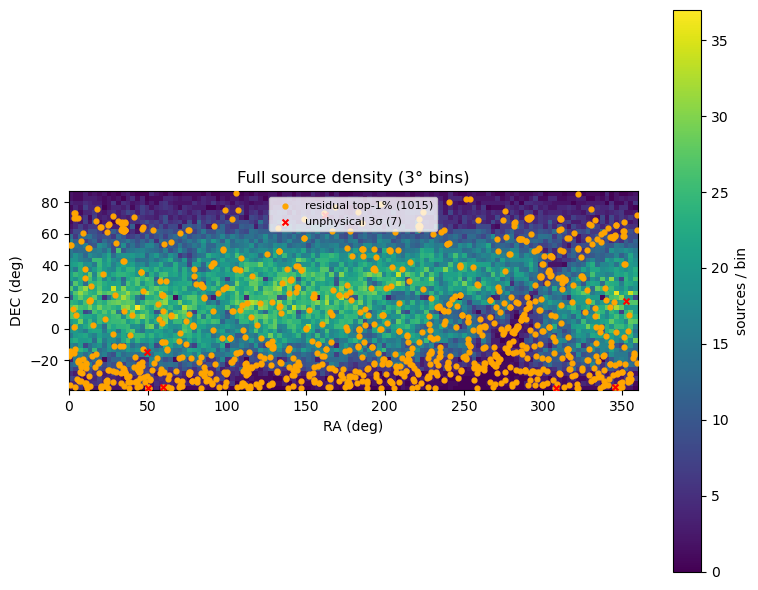


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,Full,63059,1015,7,37,4
1,Blue,135778,2043,20,66,5
2,Green,72372,1126,1,38,0
3,Red,27646,432,0,18,0


In [12]:
import matplotlib.pyplot as plt

# Full-band 1° density map + flagged overlays; roll-up for all bands
primary_band = "Full" if "Full" in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)
